In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Fixer le style pour de beaux graphiques
sns.set_theme(style="whitegrid")

# Charger le jeu de données
df = pd.read_csv('../data/customer_churn_business_dataset.csv') # Ajuste le chemin si besoin

# Afficher les dimensions globales
print(f"Dimensions du dataset : {df.shape[0]} lignes (clients) et {df.shape[1]} colonnes.\n")

# Voir les types de colonnes et la présence de valeurs manquantes initiales
df.info()

Dimensions du dataset : 10000 lignes (clients) et 32 colonnes.

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             10000 non-null  str    
 1   gender                  10000 non-null  str    
 2   age                     10000 non-null  int64  
 3   country                 10000 non-null  str    
 4   city                    10000 non-null  str    
 5   customer_segment        10000 non-null  str    
 6   tenure_months           10000 non-null  int64  
 7   signup_channel          10000 non-null  str    
 8   contract_type           10000 non-null  str    
 9   monthly_logins          10000 non-null  int64  
 10  weekly_active_days      10000 non-null  int64  
 11  avg_session_time        10000 non-null  float64
 12  features_used           10000 non-null  int64  
 13  usage_growth_rate       10000 non-null 

In [2]:
# Résumé statistique des variables catégorielles (textes)
df.describe(include='O').T

C:\Users\Pret Jeff\AppData\Local\Temp\ipykernel_34088\1861697496.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='O').T


,count,unique,top,freq
customer_id,10000,10000,CUST_00001,1
gender,10000,2,Male,5013
country,10000,7,Bangladesh,1494
city,10000,7,London,1518
customer_segment,10000,3,Individual,5984
signup_channel,10000,3,Web,5036
contract_type,10000,3,Monthly,4967
payment_method,10000,3,Card,5955
discount_applied,10000,2,No,6950
price_increase_last_3m,10000,2,No,8055


In [3]:
# Zoom sur l'incohérence géographique
print("Distribution des pays pour les résidents de Londres :")
print(df[df['city'] == 'London']['country'].value_counts())

Distribution des pays pour les résidents de Londres :
country
Australia     235
Bangladesh    224
India         220
Canada        219
USA           215
Germany       203
UK            202
Name: count, dtype: int64


In [4]:
# Suppression de la colonne problématique
df = df.drop(columns=['country'])
print("Colonne 'country' éliminée pour cause d'incohérence géopolitique.")

Colonne 'country' éliminée pour cause d'incohérence géopolitique.


Clients fidèles (0) : 8979 (89.79%)
Clients partis (1)  : 1021 (10.21%)


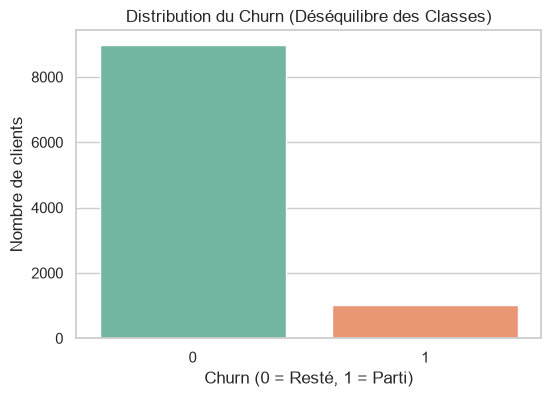

In [5]:
# Calcul des proportions
churn_counts = df['churn'].value_counts()
churn_pct = df['churn'].value_counts(normalize=True) * 100

print(f"Clients fidèles (0) : {churn_counts[0]} ({churn_pct[0]:.2f}%)")
print(f"Clients partis (1)  : {churn_counts[1]} ({churn_pct[1]:.2f}%)")

# Graphique de répartition
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='churn', hue='churn', legend=False, palette='Set2')
plt.title("Distribution du Churn (Déséquilibre des Classes)")
plt.xlabel("Churn (0 = Resté, 1 = Parti)")
plt.ylabel("Nombre de clients")
plt.show()

In [6]:
# Nombre de valeurs manquantes par colonne
missing_data = df.isnull().sum()
print("Valeurs manquantes par colonne :\n", missing_data[missing_data > 0])

Valeurs manquantes par colonne :
 complaint_type    2045
dtype: int64


In [7]:
# Comparaison des moyennes des variables numériques selon le statut de Churn
numerical_analysis = df.groupby('churn').mean(numeric_only=True).T
print("Moyennes des variables selon le Churn :\n", numerical_analysis)

Moyennes des variables selon le Churn :
 churn                           0           1
age                     45.849872   46.400588
tenure_months           30.830382   24.222331
monthly_logins          19.998218   16.803134
weekly_active_days       3.486246    3.419197
avg_session_time        15.198622   15.093508
features_used            4.986747    5.026445
usage_growth_rate        0.019157    0.021763
last_login_days_ago      9.382114   10.587659
monthly_fee             34.970487   34.573947
total_revenue         1081.138211  844.897160
payment_failures         0.473995    0.738492
support_tickets          1.206482    1.207640
avg_resolution_time     23.984006   23.682382
csat_score               3.538813    3.028404
escalations              0.292349    0.309500
email_open_rate          0.498711    0.507512
marketing_click_rate     0.253673    0.252713
nps_score               19.071166   19.456415
referral_count           0.994654    0.970617


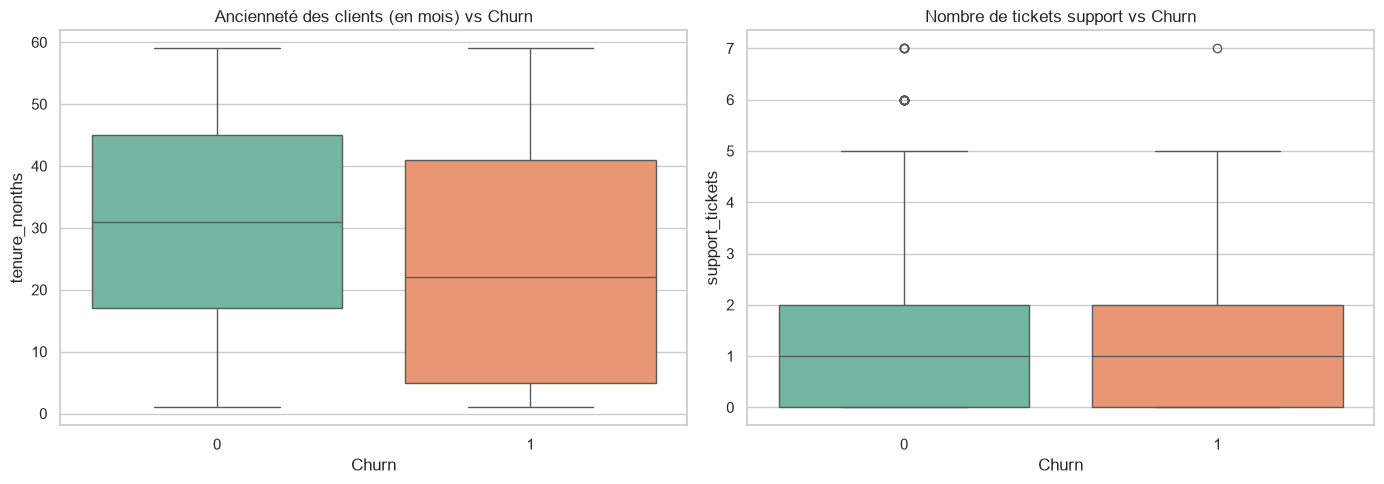

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot de l'ancienneté
sns.boxplot(data=df, x='churn', y='tenure_months', ax=axes[0], palette='Set2', hue='churn', legend=False)
axes[0].set_title("Ancienneté des clients (en mois) vs Churn")
axes[0].set_xlabel("Churn")

# Boxplot des tickets de support
sns.boxplot(data=df, x='churn', y='support_tickets', ax=axes[1], palette='Set2', hue='churn', legend=False)
axes[1].set_title("Nombre de tickets support vs Churn")
axes[1].set_xlabel("Churn")

plt.tight_layout()
plt.show()